# How to Parrallelize Bulk Text Embeddings Load on Snowflake

### Import snowpark libraries

In [217]:
from snowflake.snowpark import Session
from snowflake.snowpark.functions import col, max as _max
import json
import pandas as pd

### Connect to Snowflake with a Snowpark Session

In [276]:
with open('creds.json') as f:
    data = json.load(f)
    USERNAME = data['username']
    PASSWORD = data['password']
    ROLE = data['role']
    ACCOUNT = data['account']
    WAREHOUSE = data['warehouse']
    DATABASE = data['database']
    SCHEMA = data['schema']

CONNECTION_PARAMETERS = {
   "account": ACCOUNT,
   "user": USERNAME,
   "password": PASSWORD,
   "role": ROLE, 
   "database": DATABASE,
   "warehouse": WAREHOUSE,
   "schema": SCHEMA
}

session = Session.builder.configs(CONNECTION_PARAMETERS).create()
session.get_current_warehouse()

'"XS_WH"'

### Create this SP directly on Snowflake worksheet

In [219]:
# pdf_chunker ="""
# create or replace procedure pdf_text_chunker(file_url string,relative_path string, size int, table_name string)
# returns string
# language python
# runtime_version = '3.9'
# handler = 'main'
# packages = ('snowflake-snowpark-python','PyPDF2', 'langchain')
# as
# $$
# from snowflake.snowpark import Session
# from snowflake.snowpark.types import StringType, StructField, StructType
# from langchain.text_splitter import RecursiveCharacterTextSplitter
# from snowflake.snowpark.files import SnowflakeFile
# import PyPDF2, io
# import logging
# import pandas as pd


# def read_pdf(file_url: str) -> str:

#     logger = logging.getLogger("udf_logger")
#     logger.info(f"Opening file {file_url}")

#     with SnowflakeFile.open(file_url, 'rb') as f:
#         buffer = io.BytesIO(f.readall())
        
#     reader = PyPDF2.PdfReader(buffer)   
#     text = ""
#     for page in reader.pages:
#         try:
#             text += page.extract_text().replace('\n', ' ').replace('\0', ' ')
#         except:
#             text = "Unable to Extract"
#             logger.warn(f"Unable to extract from file {file_url}, page {page}")
    
#     return text
    
# def main(session:Session, file_url,relative_path,size,table_name):
#         text = read_pdf(file_url)
#         text_splitter = RecursiveCharacterTextSplitter(
#             chunk_size = 4000, #Adjust this as you see fit
#             chunk_overlap  = 400, #This let's text have some form of overlap. Useful for keeping chunks contextual
#             length_function = len
#         )
#         chunks = text_splitter.split_text(text)
#         df = pd.DataFrame(chunks, columns=['chunks'])
#         df['RELATIVE_PATH'] = relative_path
#         df['SIZE'] = size
#         df =df[['RELATIVE_PATH','SIZE','chunks']]
#         session.write_pandas(df,table_name,auto_create_table=True, table_type="transient")
#         return 'Done'
# $$;
# """
# session.sql(pdf_chunker).collect()

### Create the number of warehouse batches and bucket size per Warehouse. 
##### Recommend to atleast operate on 30 warehouses
##### Make sure you atleast have 80 tasks per parent (wrhs)

In [220]:
session.sql ("set wrhs_batch_size = 5;").collect()
session.sql ("set bucket_size = 80;").collect()
generate_matrix = '''
create OR REPLACE table to_process AS 
select b.wrhs_batch,a.bucket,a.relative_path,a.size,'NOT PROCESSED' STATUS
from
(select  NTILE($wrhs_batch_size*$bucket_size) OVER (ORDER BY relative_path) AS bucket,relative_path,size from DIRECTORY(@RAG_DOCS)) a
join
(SELECT  NTILE($wrhs_batch_size) OVER (ORDER BY relative_path) AS wrhs_batch,relative_path,size FROM DIRECTORY(@RAG_DOCS)) b
on a.relative_path = b.relative_path;'''
session.sql (generate_matrix).collect()

[Row(status='Table TO_PROCESS successfully created.')]

### Create the batches alligning to the number of warehouses

In [221]:
batch = session.sql("select distinct wrhs_batch from to_process").to_pandas()

In [227]:
warehouse_create = '''CREATE OR REPLACE WAREHOUSE WRHS_PDF_CHUNK_{0} 
  WAREHOUSE_TYPE = 'STANDARD'
  WAREHOUSE_SIZE = 'XSMALL'
  AUTO_SUSPEND = 1800
  MAX_CLUSTER_COUNT = 10
  MIN_CLUSTER_COUNT = 1
  SCALING_POLICY = STANDARD;
  '''
for index, row in batch.iterrows():
    session.sql(warehouse_create.format(row['WRHS_BATCH'])).collect()

In [228]:
# base_chunks_table = '''create or replace TRANSIENT TABLE TEST_CHUNKS{0} (
#     RELATIVE_PATH VARCHAR,
#     SIZE NUMBER(38,0),
#     "chunks" VARCHAR
# );'''
# for index, row in batch.iterrows():
#     session.sql(base_chunks_table.format(row['WRHS_BATCH'])).collect()

### Create the test chunks tables where the embeddings will be stored

In [229]:
base_chunks_table = '''create or replace TRANSIENT TABLE TEST_CHUNKS (
    RELATIVE_PATH VARCHAR,
    SIZE NUMBER(38,0),
    "chunks" VARCHAR
);'''
session.sql(base_chunks_table).collect()

[Row(status='Table TEST_CHUNKS successfully created.')]

### Create as many root pdf chunk tasks per warehouse.

In [231]:
base_parent_task = '''CREATE OR REPLACE TASK ROOT_PDF_CHUNK{0}
  user_task_timeout_ms = 18000000
  WAREHOUSE = WRHS_PDF_CHUNK_{0} 
  SCHEDULE = '5 minute'
  AS
    SELECT CURRENT_TIME;'''
# for row in batch.to_local_iterator():
for index, row in batch.iterrows():
    session.sql(base_parent_task.format(row['WRHS_BATCH'])).collect()

### Create the bucketized tasks per parent root task

In [232]:
to_process = session.sql("select distinct wrhs_batch, bucket from to_process").to_pandas()

In [233]:
base_child_task = '''CREATE OR REPLACE TASK PDF_CHUNK{1}
  WAREHOUSE = WRHS_PDF_CHUNK_{0} 
  user_task_timeout_ms = 18000000
  AFTER ROOT_PDF_CHUNK{0}
AS
BEGIN
    LET c1 CURSOR FOR SELECT * FROM TO_PROCESS WHERE WRHS_BATCH = {0} AND BUCKET = {1};
    FOR record IN c1 DO
        LET relative_path VARCHAR := record.relative_path;
        LET size INT := record.size;
        CALL pdf_text_chunker(BUILD_SCOPED_FILE_URL(@RAG_DOCS,:relative_path),:relative_path,:size, 'TEST_CHUNKS');
    END FOR;
END;'''

In [234]:
# for row in to_process.to_local_iterator():
for index, row in to_process.iterrows():
    session.sql(base_child_task.format(row['WRHS_BATCH'], row['BUCKET'])).collect()

### DAG of tasks display under the Database

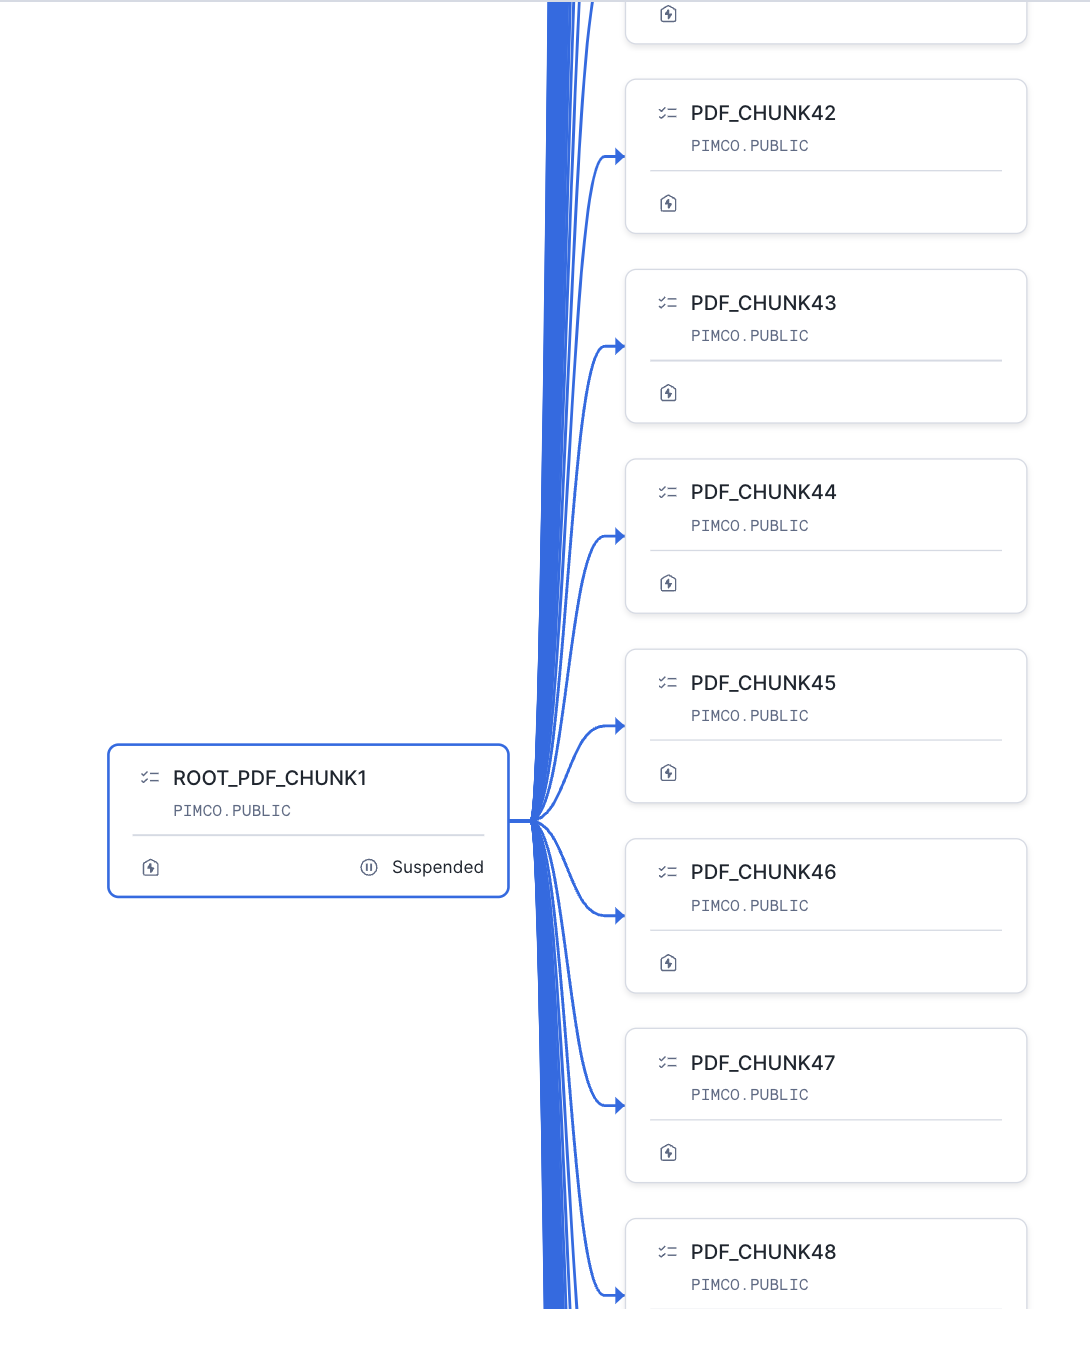

In [291]:
from IPython.display import Image
Image(filename='DAG of Tasks.png') 

### Resume all child tasks and execute the parent tasks.
#### Assume There are 100 parent tasks and each parent task has 80 child tasks == Total of 8100 tasks will execute across 100 warehouse

In [235]:
resume_tasks = '''alter task PDF_CHUNK{0} resume;'''
execute_parent_task = '''execute task ROOT_PDF_CHUNK{0};'''
print (resume_tasks.format(12))
print (execute_parent_task.format(1))

alter task PDF_CHUNK12 resume;
execute task ROOT_PDF_CHUNK1;


In [236]:
# for row in to_process.to_local_iterator():
for index, row in to_process.iterrows():  
    session.sql(resume_tasks.format(row['BUCKET'])).collect()

# STOP HERE and validate the tasks in Snowflake DB before you proceed with next step

In [238]:
# for row in batch.to_local_iterator():
for index,row in batch.iterrows():
    session.sql(execute_parent_task.format(row['WRHS_BATCH'])).collect()

### Monitor Warehouse Usage on Snowflake

### When All tasks are fully active

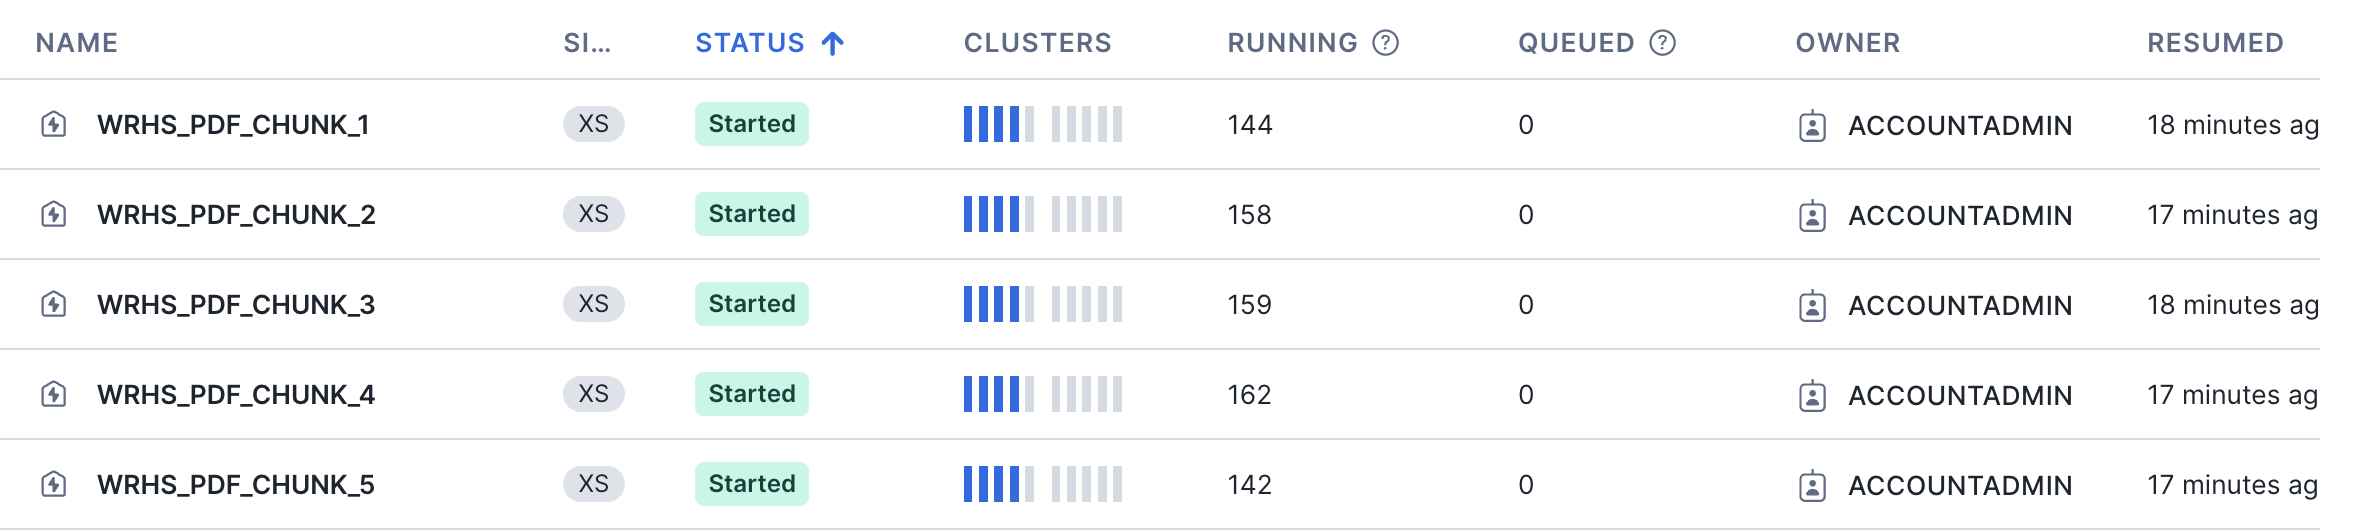

In [300]:
from IPython.display import Image
Image(filename='Multicluster warehouse.png') 

### Monitor Load Execution

In [326]:
exec_monitor = '''SELECT 
'XS Multi Cluster' as Warehouse_size,
c.total_pdf_files,
round(c.avg_pdf_size)/1000000 as avg_pdf_size_in_mb,
b.records as total_embed_chunks, 
timestampdiff('minutes', query_start_time,nvl(completed_time,current_timestamp))  elapsed_mins,
name, 
query_start_time, 
completed_time,
root_task_id
FROM TABLE(INFORMATION_SCHEMA.TASK_HISTORY()) 
join 
(select COUNT(*) as records from test_chunks) b
join
(select count(*) as total_pdf_files, avg(size) avg_pdf_size from directory(@rag_docs)) c
where 
databasE_name = 'PIMCO' and 
name like 'PDF_CHUNK%'
ORDER BY query_start_time asc
limit 1'''
session.sql(exec_monitor).show()

-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
|"WAREHOUSE_SIZE"  |"TOTAL_PDF_FILES"  |"AVG_PDF_SIZE_IN_MB"  |"TOTAL_EMBED_CHUNKS"  |"ELAPSED_MINS"  |"NAME"        |"QUERY_START_TIME"                |"COMPLETED_TIME"                  |"ROOT_TASK_ID"                        |
-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
|XS Multi Cluster  |10001              |4.748494              |5306838               |45              |PDF_CHUNK199  |2024-04-27 16:40:00.386000-07:00  |2024-04-27 17:25:45.330000-07:00  |01b3f586-88e4-affc-0000-000000000a3b  |
----------------------------------------------------------------------------------------

### When the tasks have completed and very few tasks left, See how the clusters scale down

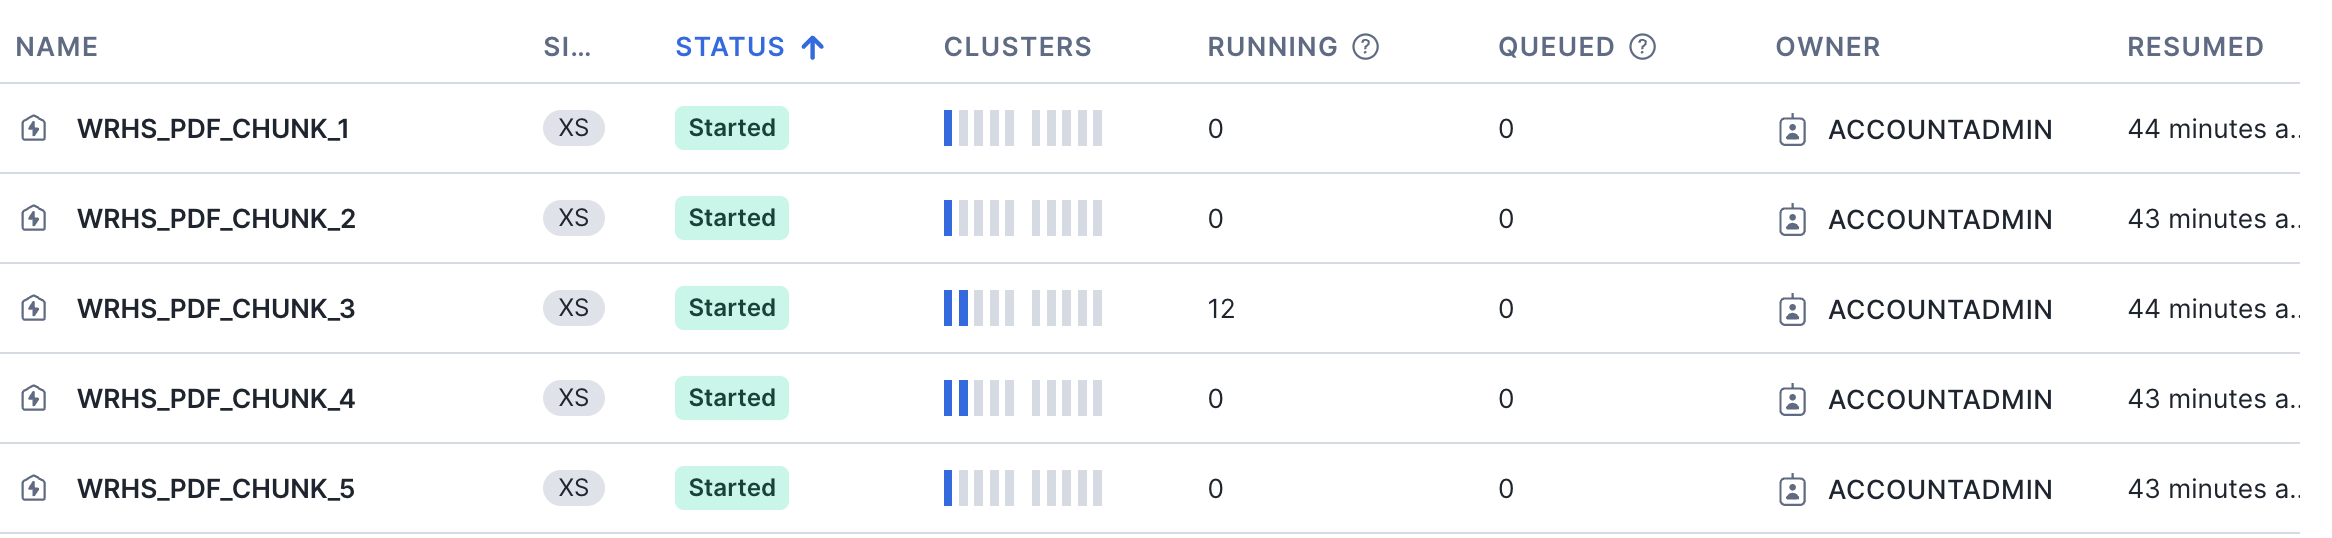

In [325]:
from IPython.display import Image
Image(filename='MultiCluster warehosue towards End.png') 

In [275]:
session.close()